In [22]:
# Activity2, individual assignment
# Setup and data loading
# Convert numeric-like columns
num_like = ["fare", "distance", "passengers", "seats"]
for col in num_like:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert object-like columns
obj_like = ["carrier", "origin", "destination"]
for col in obj_like:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
# Basic inspection
print("Shape:", df.shape)
print("\nColumns and dtypes:\n", df.dtypes)
print("\nHead:\n", df.head(10))


Shape: (245955, 23)

Columns and dtypes:
 tbl                object
year                int64
quarter             int64
citymarketid_1      int64
citymarketid_2      int64
city1              object
city2              object
airportid_1         int64
airportid_2         int64
airport_1          object
airport_2          object
nsmiles             int64
passengers          int64
fare              float64
carrier_lg         object
large_ms          float64
fare_lg           float64
carrier_low        object
lf_ms             float64
fare_low          float64
geocoded_city1     object
geocoded_city2     object
tbl1apk            object
dtype: object

Head:
        tbl  year  quarter  citymarketid_1  citymarketid_2  \
0  Table1a  2021        3           30135           33195   
1  Table1a  2021        3           30135           33195   
2  Table1a  2021        3           30140           30194   
3  Table1a  2021        3           30140           30194   
4  Table1a  2021        3        

In [2]:
# Standardize column names and trim strings
# Convert column names to snake_case
def to_snake(name):
    return (
        str(name)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
        .replace(".", "_")
    )

df.columns = [to_snake(c) for c in df.columns]

# Trim whitespace in object columns
str_cols = df.select_dtypes(include=["object"]).columns
for col in str_cols:
    df[col] = df[col].astype(str).str.strip()
    # Treat empty strings as NaN
    df[col] = df[col].replace("", np.nan)


In [3]:
# Example: year, month columns -> single date
# Date parsing and type handling
if {"year", "month"}.issubset(df.columns):
    df["year"] = pd.to_numeric(df["year"], errors="coerce")
    df["month"] = pd.to_numeric(df["month"], errors="coerce")
    df["period"] = pd.to_datetime(
        dict(year=df["year"], month=df["month"], day=1),
        errors="coerce"
    )

# Example: direct date column
for col in df.columns:
    if any(k in col for k in ["date", "flight_date", "period"]):
        df[col] = pd.to_datetime(df[col], errors="coerce")


In [4]:
# Handle missing values
# Numeric: fill with mean
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    mean_val = df[col].mean()
    df[col] = df[col].fillna(mean_val)

# String/object: fill with 'Unknown'
str_cols = df.select_dtypes(include=["object"]).columns
for col in str_cols:
    df[col] = df[col].fillna("Unknown")

cleaned_df = df.copy()



                fare     passengers
count  245955.000000  245955.000000
mean      218.979587     299.476795
std        82.372486     511.389486
min        50.000000       0.000000
25%       164.620000      21.000000
50%       209.320000     113.000000
75%       262.890000     339.000000
max      3377.000000    8301.000000


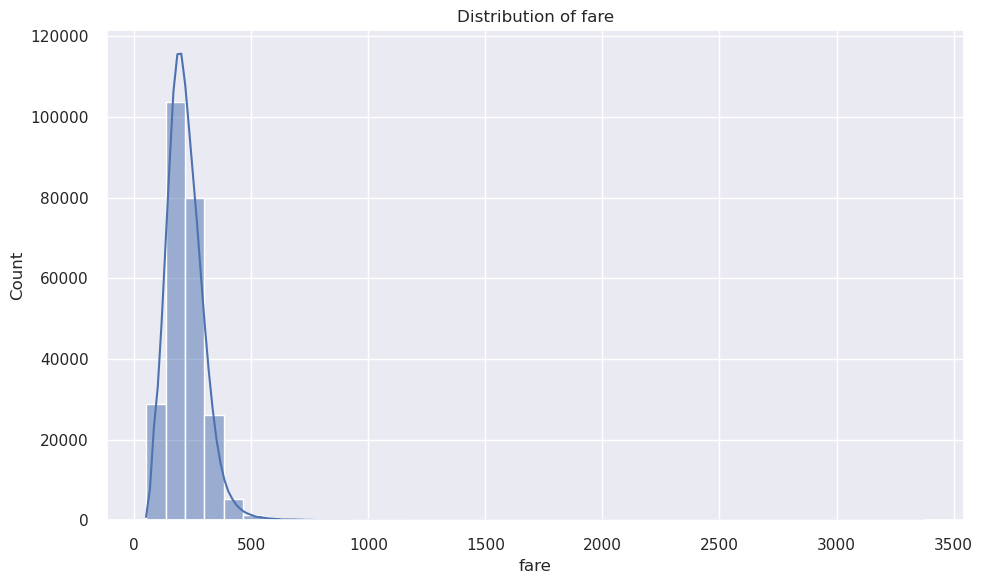

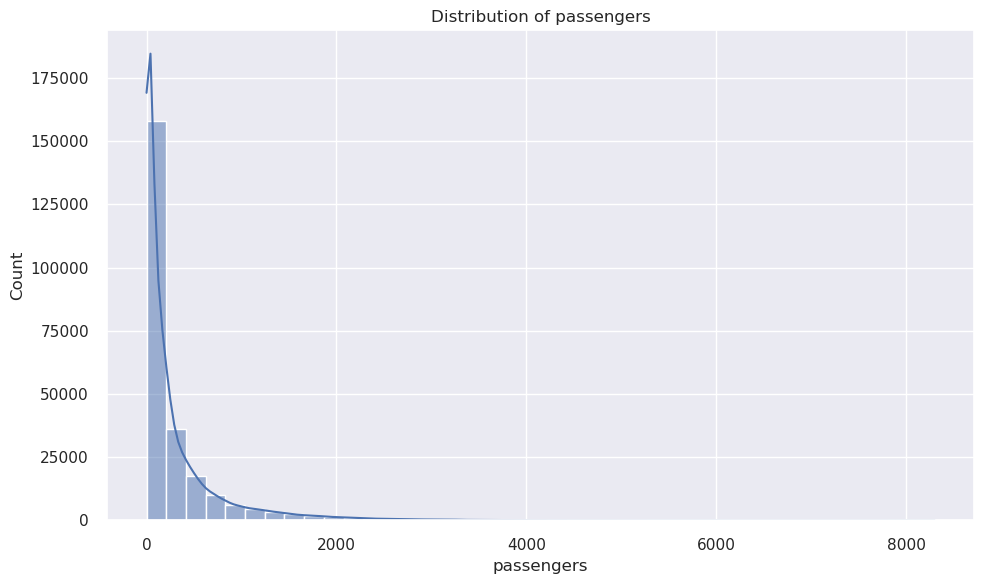

In [34]:
# Univariate analysis
key_numeric = [c for c in ["fare", "distance", "passengers", "seats"] if c in cleaned_df.columns]
print(cleaned_df[key_numeric].describe())

for col in key_numeric:
    plt.figure(figsize=(10,6))
    sns.histplot(cleaned_df[col], kde=True, bins=40)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


                fare     passengers
count  245955.000000  245955.000000
mean      218.979587     299.476795
std        82.372486     511.389486
min        50.000000       0.000000
25%       164.620000      21.000000
50%       209.320000     113.000000
75%       262.890000     339.000000
max      3377.000000    8301.000000


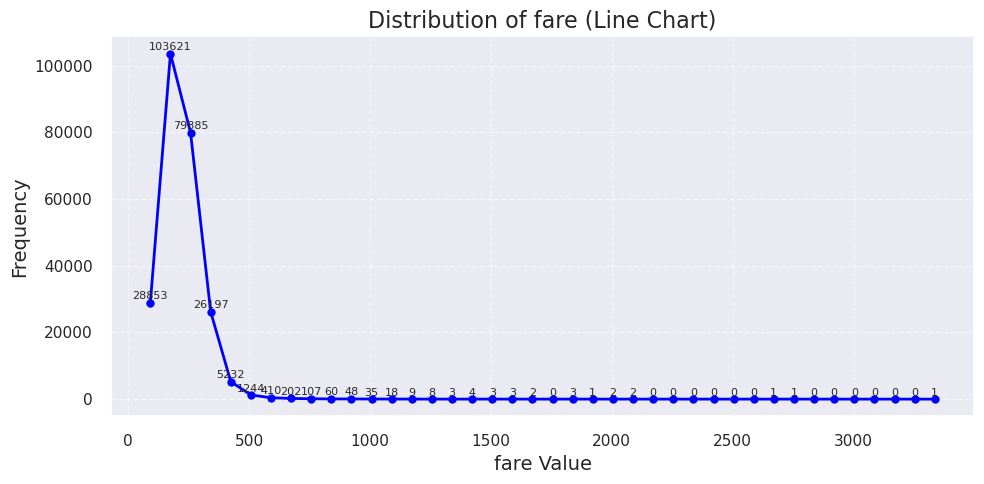

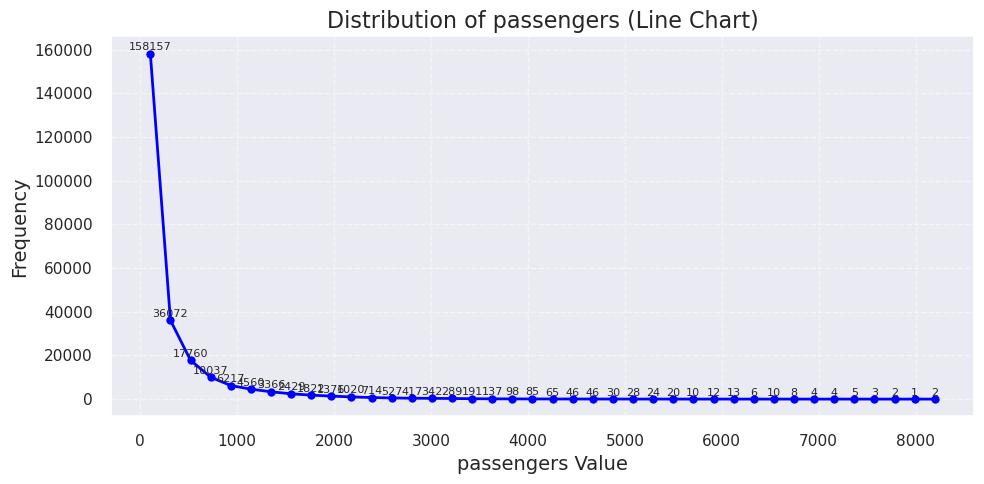

In [35]:
# Univariate analysis
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

key_numeric = [c for c in ["fare", "distance", "passengers", "seats"] if c in cleaned_df.columns]

print(cleaned_df[key_numeric].describe())

for col in key_numeric:
    plt.figure(figsize=(10,5))

    # Compute histogram bins manually
    counts, bins = np.histogram(cleaned_df[col], bins=40)

    # Convert bins to midpoints for line chart
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # Plot line chart
    plt.plot(bin_centers, counts, marker='o', linewidth=2, color='blue')

    # Add labels and title
    plt.title(f"Distribution of {col} (Line Chart)", fontsize=16)
    plt.xlabel(f"{col} Value", fontsize=14)
    plt.ylabel("Frequency", fontsize=14)

    # Add grid
    plt.grid(True, linestyle='--', alpha=0.5)

    # Annotate key points
    for x, y in zip(bin_centers, counts):
        plt.text(x, y + max(counts)*0.01, f"{y}", fontsize=8, ha='center')

    # Add global clarity
    plt.tight_layout()
    plt.show()


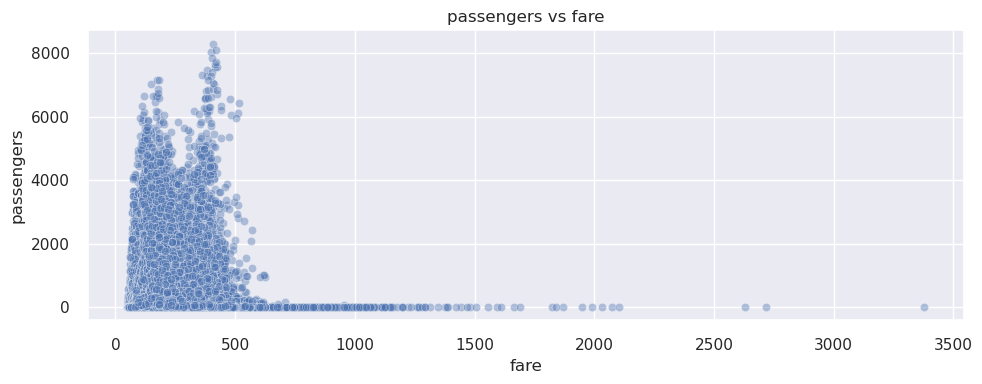

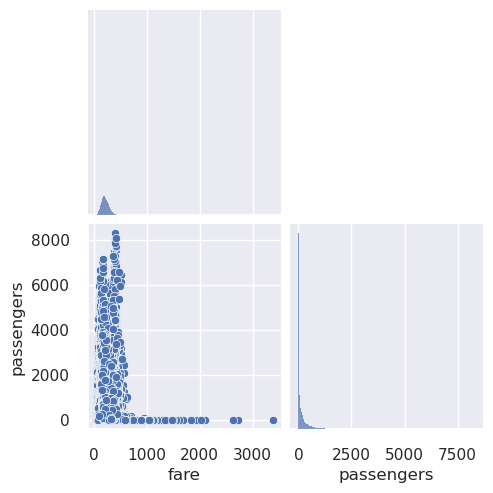

In [36]:
# Bivariate and multivariate analysis
# Example bivariate: fare vs distance, passengers vs seats
pairs = [
    ("fare", "distance"),
    ("fare", "passengers"),
    ("passengers", "seats")
]
for x, y in pairs:
    if x in cleaned_df.columns and y in cleaned_df.columns:
        plt.figure(figsize=(10,4))
        sns.scatterplot(data=cleaned_df, x=x, y=y, alpha=0.4)
        plt.title(f"{y} vs {x}")
        plt.tight_layout()
        plt.show()

# Multivariate: pairplot on key numeric
subset_cols = [c for c in key_numeric if c in cleaned_df.columns]
if len(subset_cols) >= 2:
    sns.pairplot(cleaned_df[subset_cols], corner=True)
    plt.show()


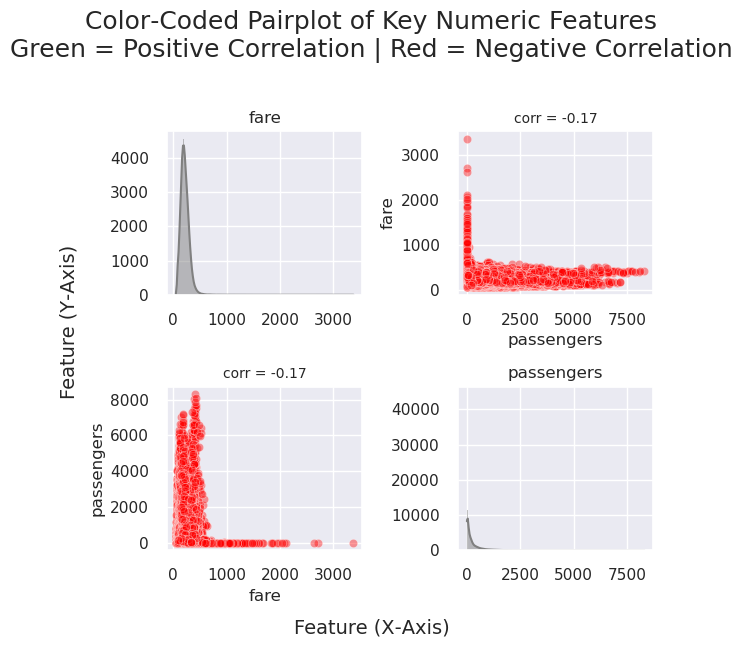

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

subset_cols = [c for c in key_numeric if c in cleaned_df.columns]

# Only proceed if at least 2 numeric columns exist
if len(subset_cols) >= 2:

    n = len(subset_cols)
    fig, axes = plt.subplots(n, n, figsize=(3*n, 3*n))

    for i, col_x in enumerate(subset_cols):
        for j, col_y in enumerate(subset_cols):

            ax = axes[i, j]

            # Diagonal: histogram
            if i == j:
                sns.histplot(cleaned_df[col_x], ax=ax, color="gray", kde=True)
                ax.set_title(f"{col_x}", fontsize=12)
                ax.set_xlabel("")
                ax.set_ylabel("")
                continue

            # Compute correlation
            corr_val = cleaned_df[[col_x, col_y]].corr().iloc[0, 1]

            # Color based on correlation sign
            color = "green" if corr_val > 0 else "red"

            # Scatterplot
            sns.scatterplot(
                data=cleaned_df,
                x=col_y,
                y=col_x,
                ax=ax,
                alpha=0.4,
                color=color
            )

            # Label correlation
            ax.set_title(f"corr = {corr_val:.2f}", fontsize=10)

            ax.set_xlabel(col_y)
            ax.set_ylabel(col_x)

    # 🔥 Add a clear global title for the entire grid
    fig.suptitle(
        "Color‑Coded Pairplot of Key Numeric Features\n"
        "Green = Positive Correlation | Red = Negative Correlation",
        fontsize=18,
        y=1.02
    )

    # 🔥 Add a global X and Y label for clarity
    fig.text(0.5, -0.02, "Feature (X‑Axis)", ha="center", fontsize=14)
    fig.text(-0.02, 0.5, "Feature (Y‑Axis)", va="center", rotation="vertical", fontsize=14)

    plt.tight_layout()
    plt.show()



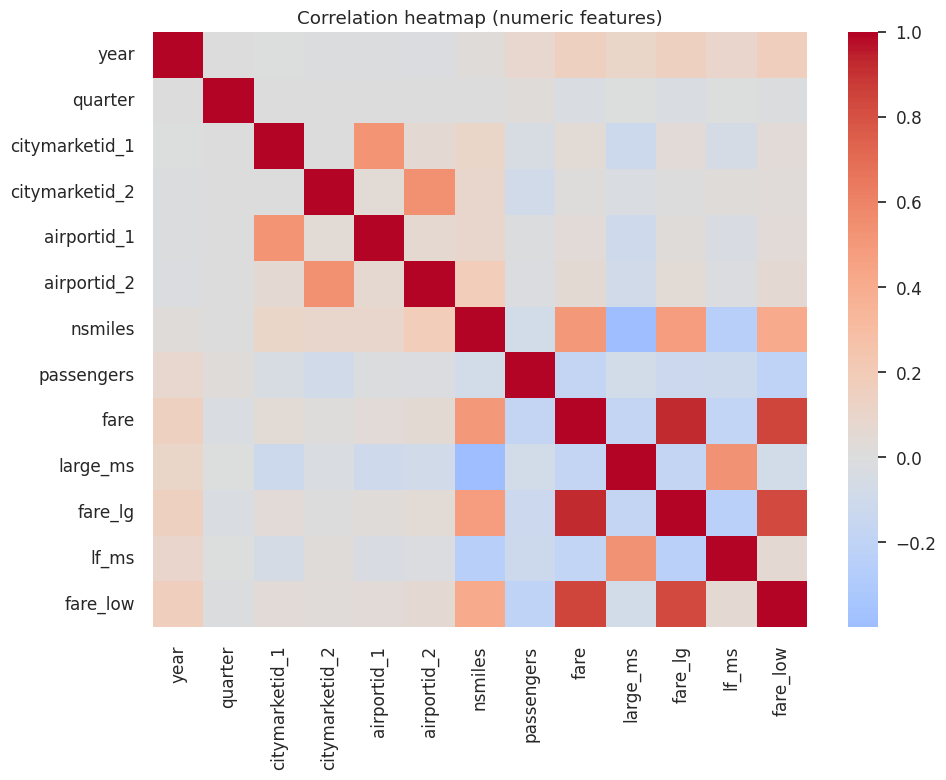


Top 10 positive correlations:
fare            fare_lg           0.920308
fare_lg         fare              0.920308
fare_low        fare              0.841732
fare            fare_low          0.841732
fare_low        fare_lg           0.827784
fare_lg         fare_low          0.827784
airportid_2     citymarketid_2    0.537673
citymarketid_2  airportid_2       0.537673
lf_ms           large_ms          0.532242
large_ms        lf_ms             0.532242
dtype: float64

Top 10 negative correlations:
lf_ms       fare         -0.181736
fare        lf_ms        -0.181736
fare_low    passengers   -0.205063
passengers  fare_low     -0.205063
lf_ms       fare_lg      -0.235554
fare_lg     lf_ms        -0.235554
nsmiles     lf_ms        -0.252032
lf_ms       nsmiles      -0.252032
large_ms    nsmiles      -0.399149
nsmiles     large_ms     -0.399149
dtype: float64


In [7]:
# Flatten correlation matrix
corr_unstacked = corr.where(~np.eye(corr.shape[0], dtype=bool)).unstack().dropna()
corr_sorted = corr_unstacked.sort_values(ascending=False)

top_corr = corr_sorted.head(10).reset_index()
top_corr.columns = ['feature_1', 'feature_2', 'correlation']

plt.figure(figsize=(10,5))
plt.plot(top_corr['feature_1'] + " vs " + top_corr['feature_2'], top_corr['correlation'], marker='o')
plt.xticks(rotation=45)
plt.title("Top 10 Positive Correlations (Line Chart)")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()


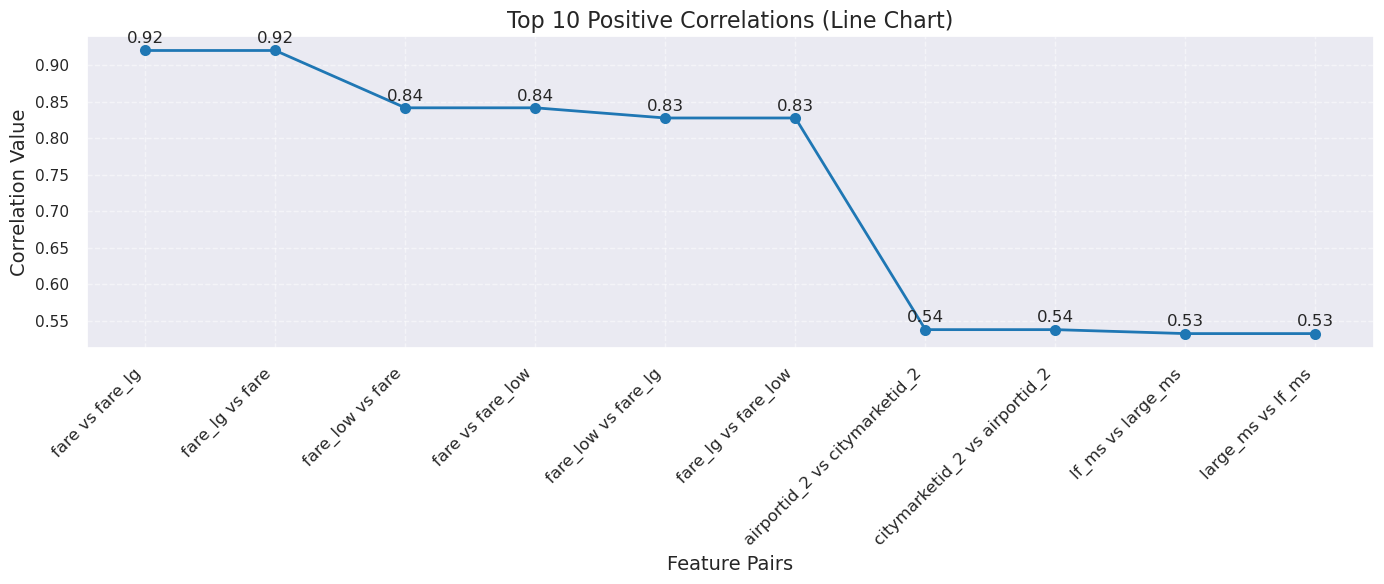

In [25]:
# Flatten correlation matrix
corr_unstacked = corr.where(~np.eye(corr.shape[0], dtype=bool)).unstack().dropna()
corr_sorted = corr_unstacked.sort_values(ascending=False)

# Top 10 correlations
top_corr = corr_sorted.head(10).reset_index()
top_corr.columns = ['feature_1', 'feature_2', 'correlation']

# Create readable labels
top_corr['label'] = top_corr['feature_1'] + " vs " + top_corr['feature_2']

plt.figure(figsize=(14,6))

plt.plot(
    top_corr['label'],
    top_corr['correlation'],
    marker='o',
    linewidth=2,
    markersize=8,
    color='tab:blue'
)

# Improve readability
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.title("Top 10 Positive Correlations (Line Chart)", fontsize=16)
plt.xlabel("Feature Pairs", fontsize=14)
plt.ylabel("Correlation Value", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

# Annotate each point with its correlation value
for i, val in enumerate(top_corr['correlation']):
    plt.text(i, val + 0.01, f"{val:.2f}", ha='center', fontsize=12)

plt.tight_layout()
plt.show()


In [45]:
df.columns




Index(['tbl', 'year', 'quarter', 'citymarketid_1', 'citymarketid_2', 'city1',
       'city2', 'airportid_1', 'airportid_2', 'airport_1', 'airport_2',
       'nsmiles', 'passengers', 'fare', 'carrier_lg', 'large_ms', 'fare_lg',
       'carrier_low', 'lf_ms', 'fare_low', 'geocoded_city1', 'geocoded_city2',
       'tbl1apk'],
      dtype='object')

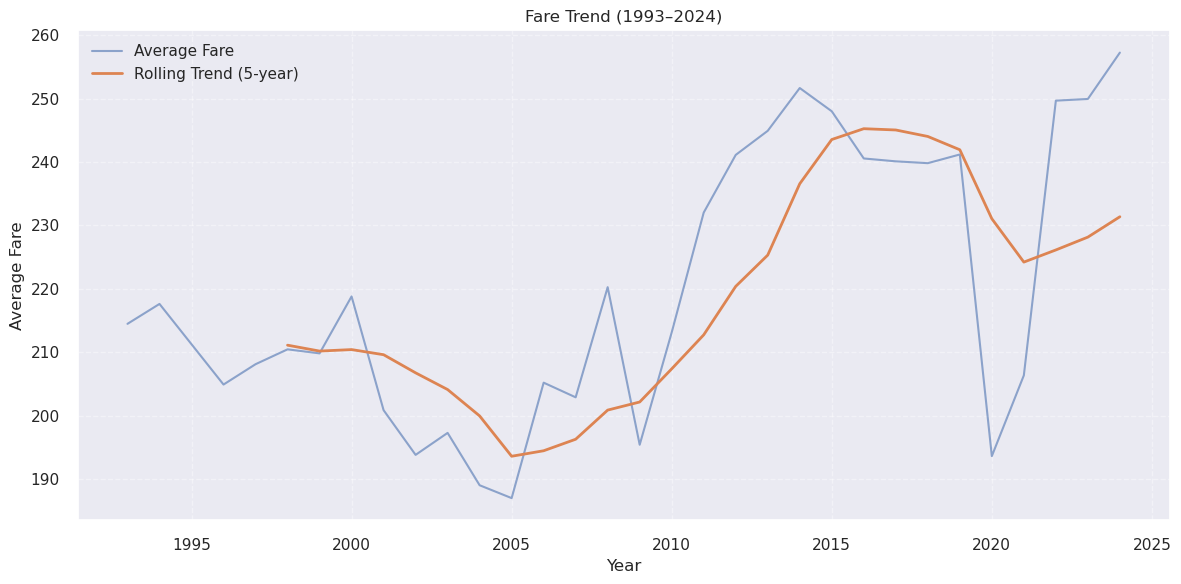

In [49]:
# Fare Trend Over Time
# Trend: Average fare per year
fare_trend = df.groupby('year')['fare'].mean().reset_index()

# Rolling trend (smooths volatility)
fare_trend['rolling_fare'] = fare_trend['fare'].rolling(window=5).mean()
# Plot the trend (line chart)
plt.figure(figsize=(12,6))

plt.plot(fare_trend['year'], fare_trend['fare'], 
         label='Average Fare', alpha=0.6)

plt.plot(fare_trend['year'], fare_trend['rolling_fare'], 
         label='Rolling Trend (5-year)', linewidth=2)

plt.title("Fare Trend (1993–2024)")
plt.xlabel("Year")
plt.ylabel("Average Fare")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



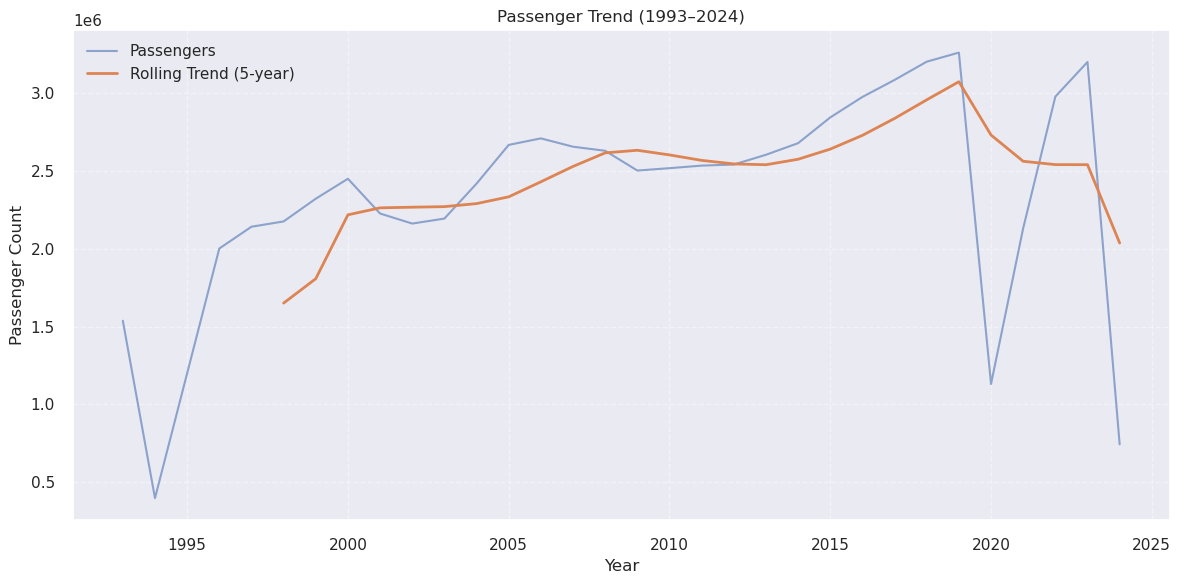

In [48]:
# Passenger Trend Over Time
passenger_trend = df.groupby('year')['passengers'].sum().reset_index()
passenger_trend['rolling_passengers'] = passenger_trend['passengers'].rolling(window=5).mean()
plt.figure(figsize=(12,6))
plt.plot(passenger_trend['year'], passenger_trend['passengers'], label='Passengers', alpha=0.6)
plt.plot(passenger_trend['year'], passenger_trend['rolling_passengers'], label='Rolling Trend (5-year)', linewidth=2)
plt.title("Passenger Trend (1993–2024)")
plt.xlabel("Year")
plt.ylabel("Passenger Count")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()




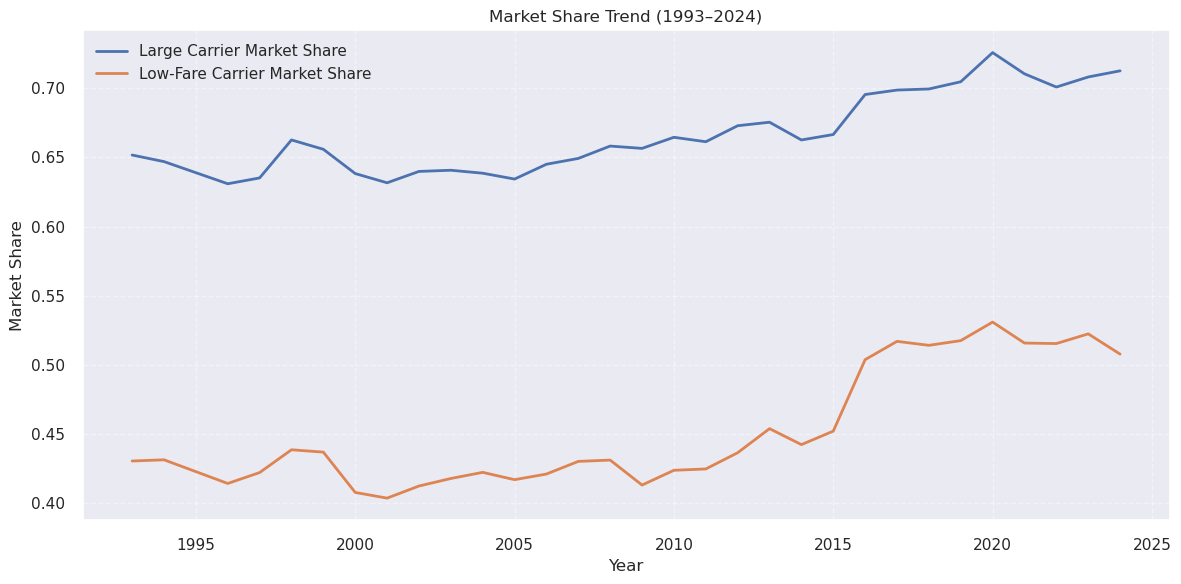

In [50]:
# Market Share Trend (Large Carrier vs Low‑Fare Carrier)
ms_trend = df.groupby('year')[['large_ms', 'lf_ms']].mean().reset_index()
plt.figure(figsize=(12,6))
plt.plot(ms_trend['year'], ms_trend['large_ms'], label='Large Carrier Market Share', linewidth=2)
plt.plot(ms_trend['year'], ms_trend['lf_ms'], label='Low-Fare Carrier Market Share', linewidth=2)
plt.title("Market Share Trend (1993–2024)")
plt.xlabel("Year")
plt.ylabel("Market Share")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


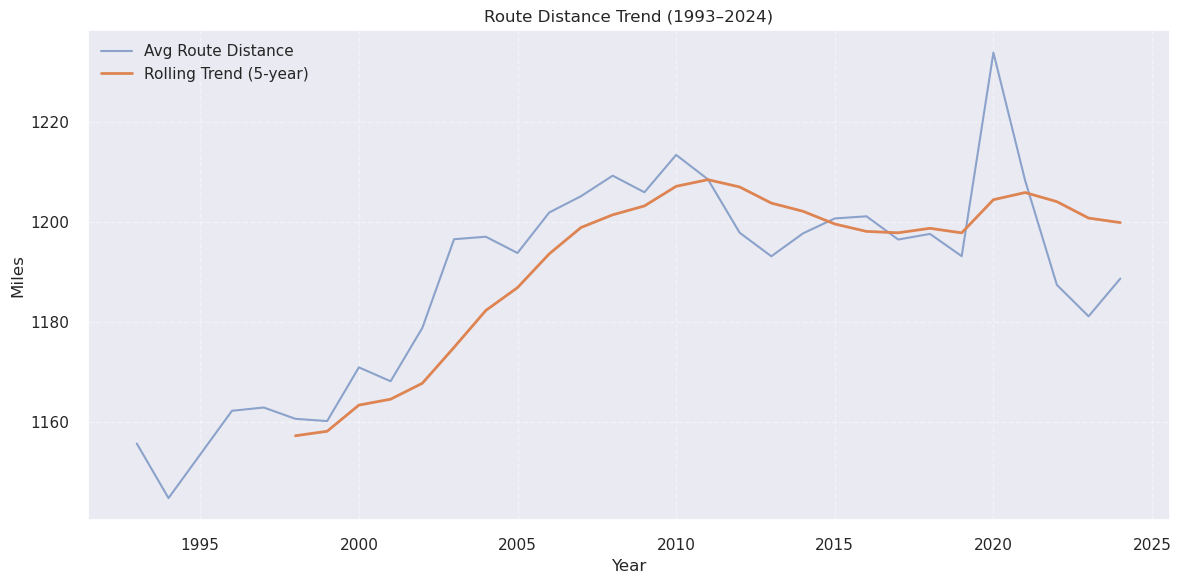

In [51]:
# Distance Trend (Route Length Over Time)
distance_trend = df.groupby('year')['nsmiles'].mean().reset_index()
distance_trend['rolling_distance'] = distance_trend['nsmiles'].rolling(window=5).mean()
plt.figure(figsize=(12,6))
plt.plot(distance_trend['year'], distance_trend['nsmiles'], label='Avg Route Distance', alpha=0.6)
plt.plot(distance_trend['year'], distance_trend['rolling_distance'], label='Rolling Trend (5-year)', linewidth=2)
plt.title("Route Distance Trend (1993–2024)")
plt.xlabel("Year")
plt.ylabel("Miles")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


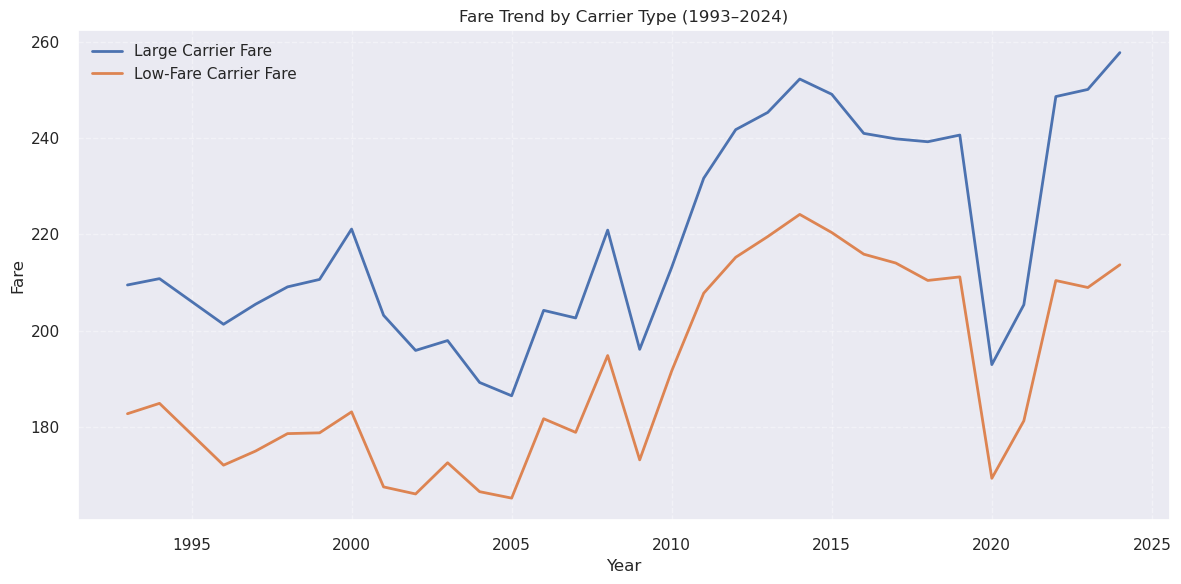

In [52]:
# Fare Trend by Carrier Type (Large vs Low‑Fare)
fare_type_trend = df.groupby('year')[['fare_lg', 'fare_low']].mean().reset_index()
plt.figure(figsize=(12,6))
plt.plot(fare_type_trend['year'], fare_type_trend['fare_lg'], label='Large Carrier Fare', linewidth=2)
plt.plot(fare_type_trend['year'], fare_type_trend['fare_low'], label='Low-Fare Carrier Fare', linewidth=2)
plt.title("Fare Trend by Carrier Type (1993–2024)")
plt.xlabel("Year")
plt.ylabel("Fare")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
